### Evaluating generative text models

In [1]:
# Let’s set up the LLM and briefly recap the text generation process we
# implemented in chapter 4. We begin by initializing the GPT model that we
# will later evaluate and train using the GPTModel class and GPT_CONFIG_124M dictionary

import torch
from gpt_2.model import GPTModel

GPT_CONFIG_124M = {
    "vocab_size": 50257,
    "context_length": 256, # We shortened the context length to 256 tokens
    "emb_dim": 768,
    "n_heads": 12,
    "n_layers": 12, 
    "drop_rate": 0.1,
    "qkv_bias": False
}

torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.eval();

In [2]:
# Let's implement the text generation process
import tiktoken
from gpt_2.model import generate_text_simple

def text_to_token_ids(text, tokenizer):
  encoded = tokenizer.encode(text, allowed_special={'<|endoftext|>'})
  encoded_tensor = torch.tensor(encoded).unsqueeze(0)
  return encoded_tensor

def token_ids_to_text(token_ids, tokenizer):
  flat = token_ids.squeeze(0)
  return tokenizer.decode(flat.tolist())

start_context = "Every effort moves you"
tokenizer = tiktoken.get_encoding('gpt2')

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(start_context, tokenizer),
    max_new_tokens=10,
    context_size=GPT_CONFIG_124M['context_length']
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you rentingetic wasnم refres RexMeCHicular stren


In [3]:
# Consider these two examples, already mapped to their respective token IDs
inputs = torch.tensor([[16833, 3626, 6100],     # ["every efforts moves",
                        [40,    1107, 588 ]])   #  "I really like"]

In [4]:
# Matching these inputs, the targets contain the token IDs we want the model to
# produce. Note that the targets are the inputs but shifted one position forward
targets = torch.tensor([[3626, 6100, 345],      # ["effort moves you",
                        [1107, 588,  11311]])   #  "really like chocolate"]

In [5]:
# Next we feed the inputs into the model and obtain probabilities from the
# returned logits with the softmax function
with torch.no_grad():
  logits = model(inputs)
probas = torch.softmax(logits, dim=-1)
print(probas.shape)

torch.Size([2, 3, 50257])


In [6]:
# Then the generate_text_simple function converts the probability scores back
# into by selecting the indexes of the embedding dimension corresponding to the
# vocab size, as we do below
token_ids = torch.argmax(probas, dim=-1)
print("Token IDs:\n", token_ids)

Token IDs:
 tensor([[16657,   339, 42826],
        [49906, 29669, 41751]])


In [7]:
# Finally, we convert the token IDs back to text
print(f"Targets batch 1: {token_ids_to_text(targets[0], tokenizer)}")
print(f"Outputs batch 1: {token_ids_to_text(token_ids[0].flatten(), tokenizer)}")

Targets batch 1:  effort moves you
Outputs batch 1:  Armed heNetflix


In [8]:
# Let's print the probabilitiy scores for the target token ids we want the model
# to predict

text_idx = 0
target_probas_1 = probas[text_idx, [0, 1, 2], targets[text_idx]]
text_idx = 1
target_probas_2 = probas[text_idx, [0, 1, 2], targets[text_idx]]
print("Text 1:\n", target_probas_1)
print("Text 2:\n", target_probas_2)

Text 1:
 tensor([7.4540e-05, 3.1061e-05, 1.1563e-05])
Text 2:
 tensor([1.0337e-05, 5.6776e-05, 4.7559e-06])


In [9]:
# We calculate the log probabilities
log_probas = torch.log(torch.cat([target_probas_1, target_probas_2]))
print(log_probas)

tensor([ -9.5042, -10.3796, -11.3677, -11.4798,  -9.7764, -12.2561])


In [10]:
# Next we average the probabilities into a single score
avg_log_probas = log_probas.mean()
print(avg_log_probas)

tensor(-10.7940)


In [11]:
# And then we multiply by -1 to obtain the average negative log likelihood
neg_avg_log_probas = avg_log_probas * -1
print(neg_avg_log_probas)

tensor(10.7940)


In [12]:
# Luckly, we don't need to do all this manually, because PyTorch has a built-in
# function for calculating the cross entropy loss given logits and targets
# Let's look at the shape of logits and targets

# The shape of logits and targets are as follows
print("Logits shape:", logits.shape)
print("Targets shape:", targets.shape)

# To apply the cross entropy function, we should combine them over the batch
# dimension, like this
logits_flat = logits.flatten(0, 1)
targets_flat = targets.flatten()
print("Flattened logits:", logits_flat.shape)
print("Flattened targets:", targets_flat.shape)

Logits shape: torch.Size([2, 3, 50257])
Targets shape: torch.Size([2, 3])
Flattened logits: torch.Size([6, 50257])
Flattened targets: torch.Size([6])


In [13]:
# Now we can apply the cross_entropy function without passing the logits through
# softmax!
loss = torch.nn.functional.cross_entropy(logits_flat, targets_flat)
print(loss)

tensor(10.7940)


In [14]:
# We can calculate perplexity by exponentiating the cross entropy loss
perplexity = torch.exp(loss)
print("Perplexity:", perplexity)

# Perplexity has a more intuitive meaning, because it tells the effective
# vocabulary size about which the model is uncertain at each step. In this case,
# the model is unsure about which among 48409 tokens in the vocabulary to generate
# as the next token

Perplexity: tensor(48725.8672)


In [15]:
# We have now calculated the loss for two small text inputs for illustration purposes.
# Next, we will apply the loss computation to the entire training and validation sets.
# We will train our model with a short text ('The Verdict' from Edith Wharton)
from gpt_2.dataset import download_pt_dataset, get_root

dowload_path = get_root().parent / 'data' / 'the-verdict.txt'
file_path = download_pt_dataset(dowload_path)
with open(file_path, 'r', encoding='utf-8') as file:
  text_data = file.read()

In [16]:
# First 99 characters
print(text_data[:99])

I HAD always thought Jack Gisburn rather a cheap genius--though a good fellow enough--so it was no 


In [17]:
# Last 99 characters
print(text_data[-99:])

it for me! The Strouds stand alone, and happen once--but there's no exterminating our kind of art."


In [18]:
# Obviously, this is a too small number of tokens
# to be used to pre-train an LLM. But this is only
# to show the steps to build a pre-train loop, later
# we will load the pre-trained weights from OpenAI

total_characters = len(text_data)
total_tokens = len(tokenizer.encode(text_data))
print("Characters:", total_characters)
print("Tokens:", total_tokens)

Characters: 20479
Tokens: 5145


In [19]:
# Split the dataset in a 90:10 train-validation
# ratio
train_ratio = 0.90
split_idx = int(len(text_data) * train_ratio)
train_data = text_data[:split_idx]
val_data = text_data[split_idx:]

In [22]:
# Create the dataloaders for the training and validation
# splits using the create_data_loader_v1 function
from gpt_2.dataset import create_data_loader_v1

torch.manual_seed(123)

train_loader = create_data_loader_v1(
    train_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M['context_length'],
    stride=GPT_CONFIG_124M['context_length'],
    drop_last=True,
    shuffle=True,
    num_workers=0,
)

val_loader = create_data_loader_v1(
    val_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M['context_length'],
    stride=GPT_CONFIG_124M['context_length'],
    drop_last=False,
    shuffle=False,
    num_workers=0,
)

print("Train Loader:")
for x, y in train_loader:
  print(x.shape, y.shape)

print("\nValidation loader:")
for x, y in val_loader:
  print(x.shape, y.shape)

Train Loader:
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])

Validation loader:
torch.Size([2, 256]) torch.Size([2, 256])


In [23]:
# Utility function to calculate the loss of a given batch returned
# by the training and validation dataloader
def calc_loss_batch(input_batch, target_batch, model, device):
  input_batch = input_batch.to(device)
  target_batch = target_batch.to(device)
  logits = model(input_batch)
  loss = torch.nn.functional.cross_entropy(
      logits.flatten(0, 1),
      target_batch.flatten()
    )

  return loss

In [24]:
# We can then use the calculate_loss_batch utility function to
# implement the calculate_loss_loader to calculate the loss for
# the whole training or validation loaders
def calc_loss_loader(data_loader, model, device, num_batches=None):
  total_loss = 0
  if len(data_loader) == 0:
    return float("nan")
  elif num_batches is None:
    num_batches = len(data_loader)
  else:
    num_batches = min(num_batches, len(data_loader))
  for i, (input_batch, target_batch) in enumerate(data_loader):
    if i < num_batches:
      loss = loss = calc_loss_batch(
          input_batch,
          target_batch,
          model,
          device
      )
      total_loss += loss.item()
    else:
      break
  return total_loss / num_batches

In [25]:
# Let's see our calc_loss_loader in action
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
torch.manual_seed(123)
with torch.no_grad():
  train_loss = calc_loss_loader(train_loader, model, device)
  val_loss = calc_loss_loader(val_loader, model, device)
print("Training loss:", train_loss)
print("Validation loss:", val_loss)

Training loss: 10.98758347829183
Validation loss: 10.98110580444336


### Training an LLM

In [26]:
# This is a simplified training loop for demonstration purpose.
# More advanced techniques for pre-training include, learning rate
# warmup, cosine annealing and gradient clipping

def train_model_simple(model, train_loader, val_loader,
                       optimizer, device, num_epochs,
                       eval_freq, eval_iter, start_context, tokenizer):
  train_losses, val_losses, track_tokens_seen = [], [], []
  tokens_seen, global_step = 0, -1

  for epoch in range(num_epochs):
    model.train()
    for input_batch, target_batch in train_loader:
      optimizer.zero_grad()
      loss = calc_loss_batch(
          input_batch, target_batch, model, device)
      loss.backward()
      optimizer.step()
      tokens_seen += input_batch.numel()
      global_step += 1

      if global_step % eval_freq == 0:
        train_loss, val_loss = evaluate_model(
            model, train_loader, val_loader, device, eval_iter)
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        track_tokens_seen.append(tokens_seen)
        print(f"Ep {epoch+1} (Step {global_step:06d}): "
              f"Train loss {train_loss:.3f}",
              f"Val loss {val_loss:.3f}"
              )

    generate_and_print_sample(model, tokenizer, device, start_context)

  return train_losses, val_losses, track_tokens_seen

In [27]:
def evaluate_model(model, train_loader, val_loader, device, eval_iter):
  model.eval()
  with torch.no_grad():
    train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
    val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)
  model.train()

  return train_loss, val_loss

In [28]:
def generate_and_print_sample(model, tokenizer, device, start_context):
  model.eval()
  context_size = model.pos_emb.weight.shape[0]
  encoded = text_to_token_ids(start_context, tokenizer)
  encoded = encoded.to(device)
  with torch.no_grad():
    token_ids = generate_text_simple(
        model=model, idx=encoded,
        max_new_tokens=50, context_size=context_size
    )
  decoded_text = token_ids_to_text(token_ids, tokenizer)
  print(decoded_text.replace("\n", " "))
  model.train()

In [29]:
# We use the AdamW optimizer to train the LLM.
# It is a modified version of the vanilla Adam optimizer
# which improves the weight decay approach, minimizing model
# complexity and preventing overfitting by penalizing larger
# model weights
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.to(device)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.0004, weight_decay=0.1
)
num_epochs = 10
train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=5, eval_iter=5,
    start_context="Every effort moves you", tokenizer=tokenizer
)


Ep 1 (Step 000000): Train loss 9.781 Val loss 9.933
Ep 1 (Step 000005): Train loss 8.111 Val loss 8.339
Every effort moves you,,,,,,,,,,,,.                                     
Ep 2 (Step 000010): Train loss 6.661 Val loss 7.048
Ep 2 (Step 000015): Train loss 5.961 Val loss 6.616
Every effort moves you, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and,, and, and,
Ep 3 (Step 000020): Train loss 5.726 Val loss 6.600
Ep 3 (Step 000025): Train loss 5.201 Val loss 6.348
Every effort moves you, and I had been.                                            
Ep 4 (Step 000030): Train loss 4.417 Val loss 6.278
Ep 4 (Step 000035): Train loss 4.069 Val loss 6.226
Every effort moves you know the                          "I he had the donkey and I had the and I had the donkey and down the room, I had
Ep 5 (Step 000040): Train loss 3.732 Val loss 6.160
Every effort moves you know it was not that the picture--I had the fact by the last I had be

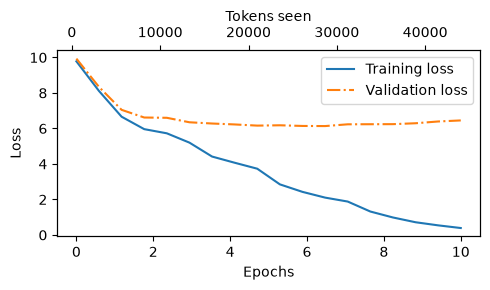

In [30]:
# Plot the train and validation losses
# We can see that the model is overfitting the training
# set but this was expected as the number of tokens is very
# low and we are training the model for multiple epochs
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
  fig, ax1 = plt.subplots(figsize=(5, 3))
  ax1.plot(epochs_seen, train_losses, label="Training loss")
  ax1.plot(epochs_seen, val_losses, linestyle="-.", label="Validation loss")
  ax1.set_xlabel("Epochs")
  ax1.set_ylabel("Loss")
  ax1.legend(loc="upper right")
  ax1.xaxis.set_major_locator(MaxNLocator(integer=True))
  ax2 = ax1.twiny()
  ax2.plot(tokens_seen, train_losses, alpha=0)
  ax2.set_xlabel("Tokens seen")
  fig.tight_layout()
  plt.show()

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

### Decoding strategies to control randomness

In [31]:
# Let's put back the model into evaluation mode and put back the model on cpu
inference_device = torch.device("cpu")
model.eval()
model.to(inference_device)

# and we plug the model into the generate_text_simple function
tokenizer = tiktoken.get_encoding('gpt2')
token_ids = generate_text_simple(
    model,
    idx=text_to_token_ids("Every effort moves you", tokenizer),
    max_new_tokens=25,
    context_size=GPT_CONFIG_124M['context_length'],
    )

# As of now the generate_text_simple function uses a 'greedy' decoding
# strategy, so even if we re-run the same generation steps multiple
# time on the same input context, we will obtain always the same generated
# text as the function takes always the tokens with the maximum output probability 
print("Output text\n", token_ids_to_text(token_ids, tokenizer))

Output text
 Every effort moves you know," was one of the axioms he laid down across the Sevres and silver of an exquisitely appointed lun


In [32]:
# To allow for mor text generation variety, we can substitute the argmax function
# in the generate_text_simple function with a function that samples from a
# probability distribution
# Let's see a practical example of this with a restricted vocabulary
vocab = {
    "closer": 0,
    "every": 1,
    "effort": 2,
    "forward": 3,
    "inches": 4,
    "moves": 5,
    "pizza": 6,
    "toward": 7,
    "you": 8,
}
inverse_vocab = {v:k for k,v in vocab.items()}

In [33]:
# Next, assume the LLM is given the start context "every effort moves you" and
# generates the following next-token logits
next_token_logits = torch.tensor(
    [4.51, 0.89, -1.90, 6.75, 1.63, -1.62, -1.89, 6.28, 1.79]
)
probas = torch.softmax(next_token_logits, dim=0)
next_token_id = torch.argmax(probas).item()
print(inverse_vocab[next_token_id])

forward


In [34]:
# to implement a probabilistic sampling process, we can substitute the
# torch.argmax function with torch.multinomial
torch.manual_seed(123)
next_token_id = torch.multinomial(probas, num_samples=1).item()
print(inverse_vocab[next_token_id])

forward


In [35]:
# 'forward' is again selected because the probability of it being selected is
# equal to its entry into the probas vector. However, if we repeat the sampling
# process multiple times we can see that the selection process is in fact
# probabilistic and not deterministic
def print_sampled_tokens(probas):
  torch.manual_seed(123)
  sample = [torch.multinomial(probas, num_samples=1).item()
            for i in range(1_000)]
  sampled_ids = torch.bincount(torch.tensor(sample), minlength=len(probas))
  for i, freq in enumerate(sampled_ids):
    print(f"{freq} x {inverse_vocab[i]}")

print_sampled_tokens(probas)

73 x closer
0 x every
0 x effort
582 x forward
2 x inches
0 x moves
0 x pizza
343 x toward
0 x you


In [37]:
# We can further control the distribution and token selection process via a
# concept called temperature scaling. Temperature scaling is just a fancy description
# for dividing the logits by a number greater than 0
def softmax_with_temperature(logits, temperature):
  scaled_logits = logits / temperature
  return torch.softmax(scaled_logits, dim=0)

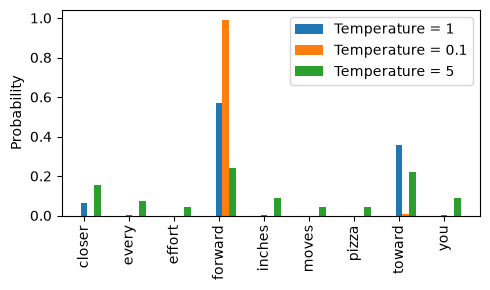

In [38]:
# Let's plot probabilites outputs of softmax with the added temperature parameter
# for different values of the temperature
temperatures = [1, 0.1, 5]
scaled_probas = [softmax_with_temperature(next_token_logits, T) for T in temperatures]
x = torch.arange(len(vocab))
bar_width = 0.15
fig, ax = plt.subplots(figsize=(5, 3))
for i, T in enumerate(temperatures):
  rects = ax.bar(x + i * bar_width, scaled_probas[i], bar_width, label=f"Temperature = {T}")
ax.set_ylabel("Probability")
ax.set_xticks(x)
ax.set_xticklabels(vocab.keys(), rotation=90)
ax.legend()
plt.tight_layout()
plt.show()

In [39]:
# top-k sampling, when combined with probabilistic sampling and temperature
# scaling, can improve the text generation results. In top-k sampling, we can
# restrict the sampled tokens to the top-k most likely tokens and exclude all
# other tokens from the selection process by masking their probability scores
top_k = 3
top_logits, top_pos = torch.topk(next_token_logits, top_k)
print("Top logits:", top_logits)
print("Top positions:", top_pos)

Top logits: tensor([6.7500, 6.2800, 4.5100])
Top positions: tensor([3, 7, 0])


In [40]:
new_logits = torch.where(
    condition=next_token_logits < top_logits[-1],
    input=torch.tensor(float('-inf')),
    other=next_token_logits,
)
print(new_logits)

tensor([4.5100,   -inf,   -inf, 6.7500,   -inf,   -inf,   -inf, 6.2800,   -inf])


In [41]:
topk_probas = torch.softmax(new_logits, dim=0)
print(topk_probas)

tensor([0.0615, 0.0000, 0.0000, 0.5775, 0.0000, 0.0000, 0.0000, 0.3610, 0.0000])


In [42]:
# Let's now modify the generate_text_simple function to include probabilistic
# next-token sampling, temperature scaling and top-k sampling
def generate(
    model,
    idx,
    max_new_tokens,
    context_size,
    temperature=0.0,
    top_k=None,
    eos_id=None
    ):
  for _ in range(max_new_tokens):
    idx_cond = idx[:, -context_size:]
    with torch.no_grad():
      logits = model(idx_cond)
    logits = logits[:, -1, :]
    if top_k is not None:
      top_logits, _ = torch.topk(logits, top_k)
      min_val = top_logits[:, -1]
      logits = torch.where(
          condition=logits < min_val,
          input=torch.tensor(float('-inf')).to(logits.device),
          other=logits
      )
    if temperature > 0.0:
      logits = logits / temperature
      logits = logits - logits.max(dim=-1, keepdim=True).values
      probs = torch.softmax(logits, dim=-1)
      idx_next = torch.multinomial(probs, num_samples=1)
    else:
      idx_next = torch.argmax(logits, dim=-1, keepdim=True)
    if idx_next == eos_id:
      break

    idx = torch.cat((idx, idx_next), dim=1)
  return idx

In [43]:
torch.manual_seed(123)
token_ids = generate(
    model=model,
    idx=text_to_token_ids("Every effort moves you", tokenizer).to(inference_device),
    max_new_tokens=15,
    context_size=GPT_CONFIG_124M['context_length'],
    top_k=25,
    temperature=1.4,
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you stand to work on surprise, a one of us had gone with random-


### Loading and saving model weights in PyTorch

In [44]:
# The recommended way to save a model is to save his state_dict dictionary mapping,
# each layer to its parameters. To save the state_dict dictionary, the torch.save()
# function is provided
from gpt_2.dataset import get_root

data_folder = get_root().parent / 'data'
torch.save(model.state_dict(), data_folder / 'model.pth')

In [45]:
# After saving the model's weights, we can load them into a model instance via
# load_state_dict() method
model = GPTModel(GPT_CONFIG_124M)
model.load_state_dict(torch.load(data_folder / 'model.pth', map_location=device))
model.eval();

In [46]:
# If we plan to continue pretraining of a model, it is also recommended to
# save the optimizer state. This is fundamental for complex optimizers such
# as AdamW which tracks state for each parameter to adjust learning rates
# dynamically. We can save both the state_dict and optimizer with torch.save()
torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
}, data_folder / "model_and_optimizer.pth")

In [47]:
# Then we can restore the model and optimizer states by first calling torch.load()
# to load saved data and then use the load_state_dict() method of each object
checkpoint = torch.load(data_folder / "model_and_optimizer.pth", map_location=device)
model = GPTModel(GPT_CONFIG_124M)
model.load_state_dict(checkpoint['model_state_dict'])
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=0.1)
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
model.train();

### Loading pretrained weights from OpenAI

In [ ]:
# Fortunately, OpenAI shared the weights of its pretrained GPT-2 models
# publicly, so we can load them into our own GPTModel class instances.
# However, OpenAI originally saved the weights using TensorFlow so we have
# to install it to load the weights in Python

# Using pip
# %pip install 'tensorflow>=2.15.0' 'tqdm>=4.66'

# Using uv
# %uv add 'tensorflow>=2.15.0' 'tqdm>=4.66'

In [48]:
# As the download script is pretty long, boring and not very interesting,
# we will download the weights using a pre-made script, downloading it from a
# GitHub repo
import urllib.request
url =(
    "https://raw.githubusercontent.com/rasbt/"
    "LLMs-from-scratch/main/ch05/"
    "01_main-chapter-code/gpt_download.py"
)
filename = url.split('/')[-1]
urllib.request.urlretrieve(url, filename)

('gpt_download.py', <http.client.HTTPMessage at 0x76aedba129f0>)

In [49]:
# Then we import the download_and_load_gpt2 function from that file
# and use it to load both GPT-2 architecture settings and weight
# parameters
from gpt_download import download_and_load_gpt2
settings, params = download_and_load_gpt2(
    model_size="124M", models_dir="gpt2"
)

I0000 00:00:1785750036.205848    4054 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1785750038.230143    4054 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1785750054.579592    4054 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
checkpoint: 100%|██████████| 77.0/77.0 [00:00<00:00, 23.4kiB/s]
encoder.json: 100%|██████████| 1.04M/1.04M [00:

In [50]:
# Let's now inspect the contents of settings and params
print("Settings:", settings)
print("Parameter dictionary keys:", params.keys())

Settings: {'n_vocab': 50257, 'n_ctx': 1024, 'n_embd': 768, 'n_head': 12, 'n_layer': 12}
Parameter dictionary keys: dict_keys(['blocks', 'b', 'g', 'wpe', 'wte'])


In [51]:
# Let's print the embedding layer weights
print(params['wte'])
print("Token embedding weight tensor dimensions:", params["wte"].shape)

[[-0.11010301 -0.03926672  0.03310751 ... -0.1363697   0.01506208
   0.04531523]
 [ 0.04034033 -0.04861503  0.04624869 ...  0.08605453  0.00253983
   0.04318958]
 [-0.12746179  0.04793796  0.18410145 ...  0.08991534 -0.12972379
  -0.08785918]
 ...
 [-0.04453601 -0.05483596  0.01225674 ...  0.10435229  0.09783269
  -0.06952604]
 [ 0.1860082   0.01665728  0.04611587 ... -0.09625227  0.07847701
  -0.02245961]
 [ 0.05135201 -0.02768905  0.0499369  ...  0.00704835  0.15519823
   0.12067825]]
Token embedding weight tensor dimensions: (50257, 768)


In [52]:
# Dictionary representing the differences between the different
# GPT-2 model sizes
model_configs = {
  "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
  "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
  "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
  "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

In [53]:
# We can use the settings into model_configs to update out GPT_CONFIG_124M
# dictionary we used earlier
model_name = "gpt2-small (124M)"
NEW_CONFIG = GPT_CONFIG_124M.copy()
NEW_CONFIG.update(model_configs[model_name])

In [54]:
# Remember that we changed the original context length of the gpt2-small
# model to make the training demo faster so we have to change it back to
# the original value
NEW_CONFIG.update({"context_length": 1024})

In [55]:
# As OpenAI used bias vectors for the query, key and value computations
# (these are not used anymore in modern LLMs as they do not improve performances)
# we have to match the original configuration to load the weights
NEW_CONFIG.update({"qkv_bias": True})

In [56]:
# Now we can use the new configuration to create a new instance of the GPT-2 model
gpt = GPTModel(NEW_CONFIG)
gpt.eval();

In [57]:
import numpy as np

def assign(left, right):
  """
  Check whether two tensors or arrays have the same shape and returns the
  right tensor as a trainable parameter
  """
  if left.shape != right.shape:
    raise ValueError(
        f"Shape mismatch. Left: {left.shape}, Right: {right.shape}"
    )
  # Ensure the new tensor is on the correct device and has the correct dtype
  return torch.nn.Parameter(torch.tensor(right, device=left.device, dtype=left.dtype))

In [58]:
import numpy as np

def load_weights_into_gpt(gpt, params):
    gpt.pos_emb.weight = assign(gpt.pos_emb.weight, params['wpe'])
    gpt.tok_emb.weight = assign(gpt.tok_emb.weight, params['wte'])

    for b in range(len(params["blocks"])):
        q_w, k_w, v_w = np.split(
            (params["blocks"][b]["attn"]["c_attn"])["w"], 3, axis=-1)
        gpt.trf_blocks[b].att.W_query.weight = assign(
            gpt.trf_blocks[b].att.W_query.weight, q_w.T)
        gpt.trf_blocks[b].att.W_key.weight = assign(
            gpt.trf_blocks[b].att.W_key.weight, k_w.T)
        gpt.trf_blocks[b].att.W_value.weight = assign(
            gpt.trf_blocks[b].att.W_value.weight, v_w.T)

        q_b, k_b, v_b = np.split(
            (params["blocks"][b]["attn"]["c_attn"])["b"], 3, axis=-1)
        gpt.trf_blocks[b].att.W_query.bias = assign(
            gpt.trf_blocks[b].att.W_query.bias, q_b)
        gpt.trf_blocks[b].att.W_key.bias = assign(
            gpt.trf_blocks[b].att.W_key.bias, k_b)
        gpt.trf_blocks[b].att.W_value.bias = assign(
            gpt.trf_blocks[b].att.W_value.bias, v_b)

        gpt.trf_blocks[b].att.out_proj.weight = assign(
            gpt.trf_blocks[b].att.out_proj.weight,
            params["blocks"][b]["attn"]["c_proj"]["w"].T)
        gpt.trf_blocks[b].att.out_proj.bias = assign(
            gpt.trf_blocks[b].att.out_proj.bias,
            params["blocks"][b]["attn"]["c_proj"]["b"])

        gpt.trf_blocks[b].ff.layers[0].weight = assign(
            gpt.trf_blocks[b].ff.layers[0].weight,
            params["blocks"][b]["mlp"]["c_fc"]["w"].T)
        gpt.trf_blocks[b].ff.layers[0].bias = assign(
            gpt.trf_blocks[b].ff.layers[0].bias,
            params["blocks"][b]["mlp"]["c_fc"]["b"])
        gpt.trf_blocks[b].ff.layers[2].weight = assign(
            gpt.trf_blocks[b].ff.layers[2].weight,
            params["blocks"][b]["mlp"]["c_proj"]["w"].T)
        gpt.trf_blocks[b].ff.layers[2].bias = assign(
            gpt.trf_blocks[b].ff.layers[2].bias,
            params["blocks"][b]["mlp"]["c_proj"]["b"])

        gpt.trf_blocks[b].norm1.scale = assign(
            gpt.trf_blocks[b].norm1.scale,
            params["blocks"][b]["ln_1"]["g"])
        gpt.trf_blocks[b].norm1.shift = assign(
            gpt.trf_blocks[b].norm1.shift,
            params["blocks"][b]["ln_1"]["b"])
        gpt.trf_blocks[b].norm2.scale = assign(
            gpt.trf_blocks[b].norm2.scale,
            params["blocks"][b]["ln_2"]["g"])
        gpt.trf_blocks[b].norm2.shift = assign(
            gpt.trf_blocks[b].norm2.shift,
            params["blocks"][b]["ln_2"]["b"])

    gpt.final_norm.scale = assign(gpt.final_norm.scale, params["g"])
    gpt.final_norm.shift = assign(gpt.final_norm.shift, params["b"])
    gpt.out_head.weight = assign(gpt.out_head.weight, params["wte"])

In [59]:
load_weights_into_gpt(gpt, params)
gpt.to(device);
gpt.eval();

# Let's try to generate some text
torch.manual_seed(123)
token_ids = generate(
    model=gpt,
    idx=text_to_token_ids("Every effort moves you", tokenizer).to(device),
    max_new_tokens=25,
    context_size=NEW_CONFIG['context_length'],
    top_k=50,
    temperature=1.5,
)
print("Output text:\n",  token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you toward finding an ideal new way to practice something!

What makes us want to be on top of that?


